# Diabetic Retinopathy Exploration and Modeling

This notebook explores the fundus image dataset and trains a strong transfer learning baseline for 5-class diabetic retinopathy classification.

## Why this model
- EfficientNet is a strong image backbone for medical image classification.
- It is much stronger than a small CNN trained from scratch on the same data.
- It also fits a later TensorFlow Lite export path if you want to move toward mobile deployment.

## Workflow
1. Audit the train and validation splits.
2. Visualize class balance and example images.
3. Build `tf.data` pipelines with augmentation.
4. Train EfficientNet in two stages: frozen backbone, then fine-tuning.
5. If model build fails from memory pressure, automatically fall back to a lighter EfficientNet variant.
6. Evaluate with confusion matrix, classification report, and macro F1.
7. Optionally export the trained model for later app integration.

In [2]:
# Run this once if your environment is missing packages.
# %pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn pillow

In [3]:
from pathlib import Path
import math
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    mean_squared_error,
    precision_recall_fscore_support,
    top_k_accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    )
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Kernel and environment sanity check (run before training).
import platform
import sys
from importlib.metadata import version, PackageNotFoundError

import tensorflow as tf

def pkg_version(name: str) -> str:
    try:
        return version(name)
    except PackageNotFoundError:
        return 'not installed'

print('Python executable:', sys.executable)
print('Python version   :', sys.version.split()[0])
print('Platform         :', platform.platform())
print('TensorFlow       :', tf.__version__)
print('seaborn          :', pkg_version('seaborn'))
print('pandas           :', pkg_version('pandas'))
print('numpy            :', pkg_version('numpy'))
print('scikit-learn     :', pkg_version('scikit-learn'))

all_devices = tf.config.list_physical_devices()
gpu_devices = tf.config.list_physical_devices('GPU')
print('All devices      :', all_devices)
print('GPU devices      :', gpu_devices if gpu_devices else 'None')

if '/envs/bruce/' in sys.executable.replace('\\', '/') or '/bruce/' in sys.executable.replace('\\', '/'):
    print('Kernel check      : OK (appears to be bruce)')
else:
    print('Kernel check      : WARNING (does not look like bruce)')

Python executable: /opt/anaconda3/envs/bruce/bin/python
Python version   : 3.10.20
Platform         : macOS-26.5.1-arm64-arm-64bit
TensorFlow       : 2.16.2
seaborn          : 0.13.2
pandas           : 2.3.3
numpy            : 1.26.4
scikit-learn     : 1.7.2
All devices      : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU devices      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Kernel check      : OK (appears to be bruce)


In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / 'data'
TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR = DATA_ROOT / 'val'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Mobile-first and kernel-stable defaults.
MODEL_NAME = 'EfficientNetB0'
MODEL_FALLBACK_ORDER = ['EfficientNetB0']
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE
EPOCHS_HEAD = 4
EPOCHS_FINE = 6
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 1e-5

# Conservative pipeline settings to reduce memory spikes.
MAP_PARALLEL_CALLS = 2
PREFETCH_BUFFER = 1
SHUFFLE_BUFFER = 2048

# Conservative thread limits can improve stability on laptops.
CPU_THREADS = max(1, min(4, os.cpu_count() or 1))
try:
    tf.config.threading.set_intra_op_parallelism_threads(CPU_THREADS)
    tf.config.threading.set_inter_op_parallelism_threads(CPU_THREADS)
except RuntimeError:
    pass

# Mixed precision is enabled only on CUDA GPUs for stability.
gpu_devices = tf.config.list_physical_devices('GPU')
use_mixed_precision = any('NVIDIA' in str(device) for device in gpu_devices)
if use_mixed_precision:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
else:
    tf.keras.mixed_precision.set_global_policy('float32')

print('Project root:', PROJECT_ROOT.resolve())
print('Train dir exists:', TRAIN_DIR.exists())
print('Val dir exists:', VAL_DIR.exists())
print('GPU devices:', gpu_devices)
print('Mixed precision policy:', tf.keras.mixed_precision.global_policy().name)
print('Model:', MODEL_NAME, '| Image size:', IMG_SIZE, '| Batch size:', BATCH_SIZE)
print('CPU threads:', CPU_THREADS, '| map calls:', MAP_PARALLEL_CALLS, '| prefetch:', PREFETCH_BUFFER)

Project root: /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project
Train dir exists: True
Val dir exists: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: float32
Model: EfficientNetB0 | Image size: (224, 224) | Batch size: 8
CPU threads: 4 | map calls: 2 | prefetch: 1


In [6]:
def build_file_index(split_dir: Path) -> pd.DataFrame:
    rows = []
    class_dirs = sorted([path for path in split_dir.iterdir() if path.is_dir() and not path.name.startswith('.')])

    for class_dir in class_dirs:
        for image_path in sorted(class_dir.glob('*.png')):
            rows.append({
                'split': split_dir.name,
                'label': class_dir.name,
                'file_path': str(image_path),
            })

    frame = pd.DataFrame(rows)
    frame['label_id'] = pd.Categorical(frame['label'], categories=sorted(frame['label'].unique())).codes
    return frame

train_df = build_file_index(TRAIN_DIR)
val_df = build_file_index(VAL_DIR)
classes = sorted(train_df['label'].unique())
class_to_id = {label: index for index, label in enumerate(classes)}
id_to_class = {index: label for label, index in class_to_id.items()}

train_df['label_id'] = train_df['label'].map(class_to_id)
val_df['label_id'] = val_df['label'].map(class_to_id)

print('Classes:', classes)
print('Train samples:', len(train_df))
print('Validation samples:', len(val_df))
train_df.head()

Classes: ['Mild', 'Moderate', 'Normal', 'Proliferate', 'Severe']
Train samples: 25169
Validation samples: 1261


,split,label,file_path,label_id
0,train,Mild,/Users/david/Documents/Repos/bruce/TEHI-AI-DR-...,0
1,train,Mild,/Users/david/Documents/Repos/bruce/TEHI-AI-DR-...,0
2,train,Mild,/Users/david/Documents/Repos/bruce/TEHI-AI-DR-...,0
3,train,Mild,/Users/david/Documents/Repos/bruce/TEHI-AI-DR-...,0
4,train,Mild,/Users/david/Documents/Repos/bruce/TEHI-AI-DR-...,0


In [7]:
summary_df = (
    pd.concat([train_df, val_df], ignore_index=True)
    .groupby(['split', 'label'])
    .size()
    .reset_index(name='count')
)
summary_df

,split,label,count
0,train,Mild,4746
1,train,Moderate,5000
2,train,Normal,5223
3,train,Proliferate,5200
4,train,Severe,5000
5,val,Mild,140
6,val,Moderate,292
7,val,Normal,295
8,val,Proliferate,296
9,val,Severe,238


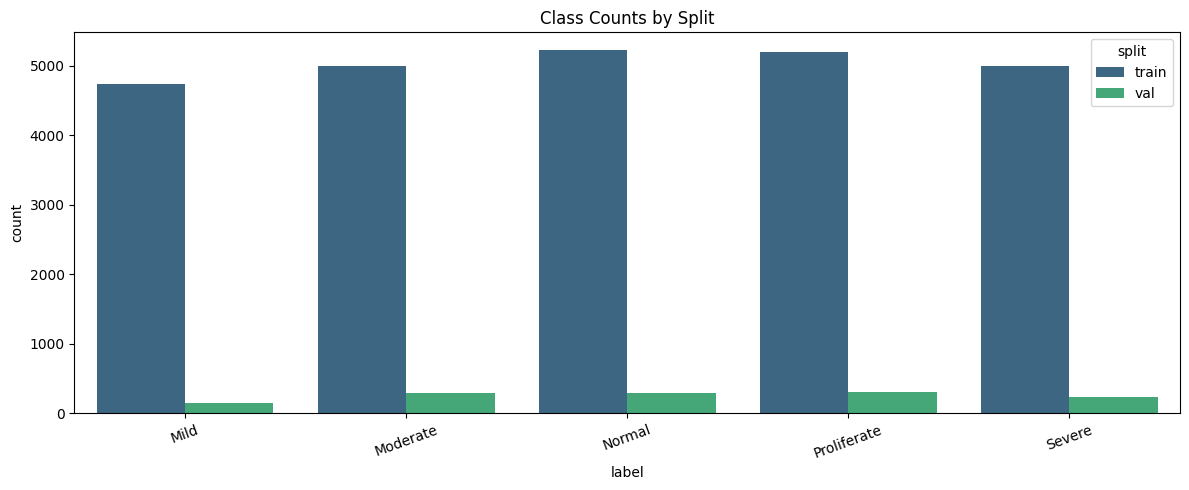

In [8]:
plt.figure(figsize=(12, 5))
sns.barplot(data=summary_df, x='label', y='count', hue='split', palette='viridis')
plt.title('Class Counts by Split')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

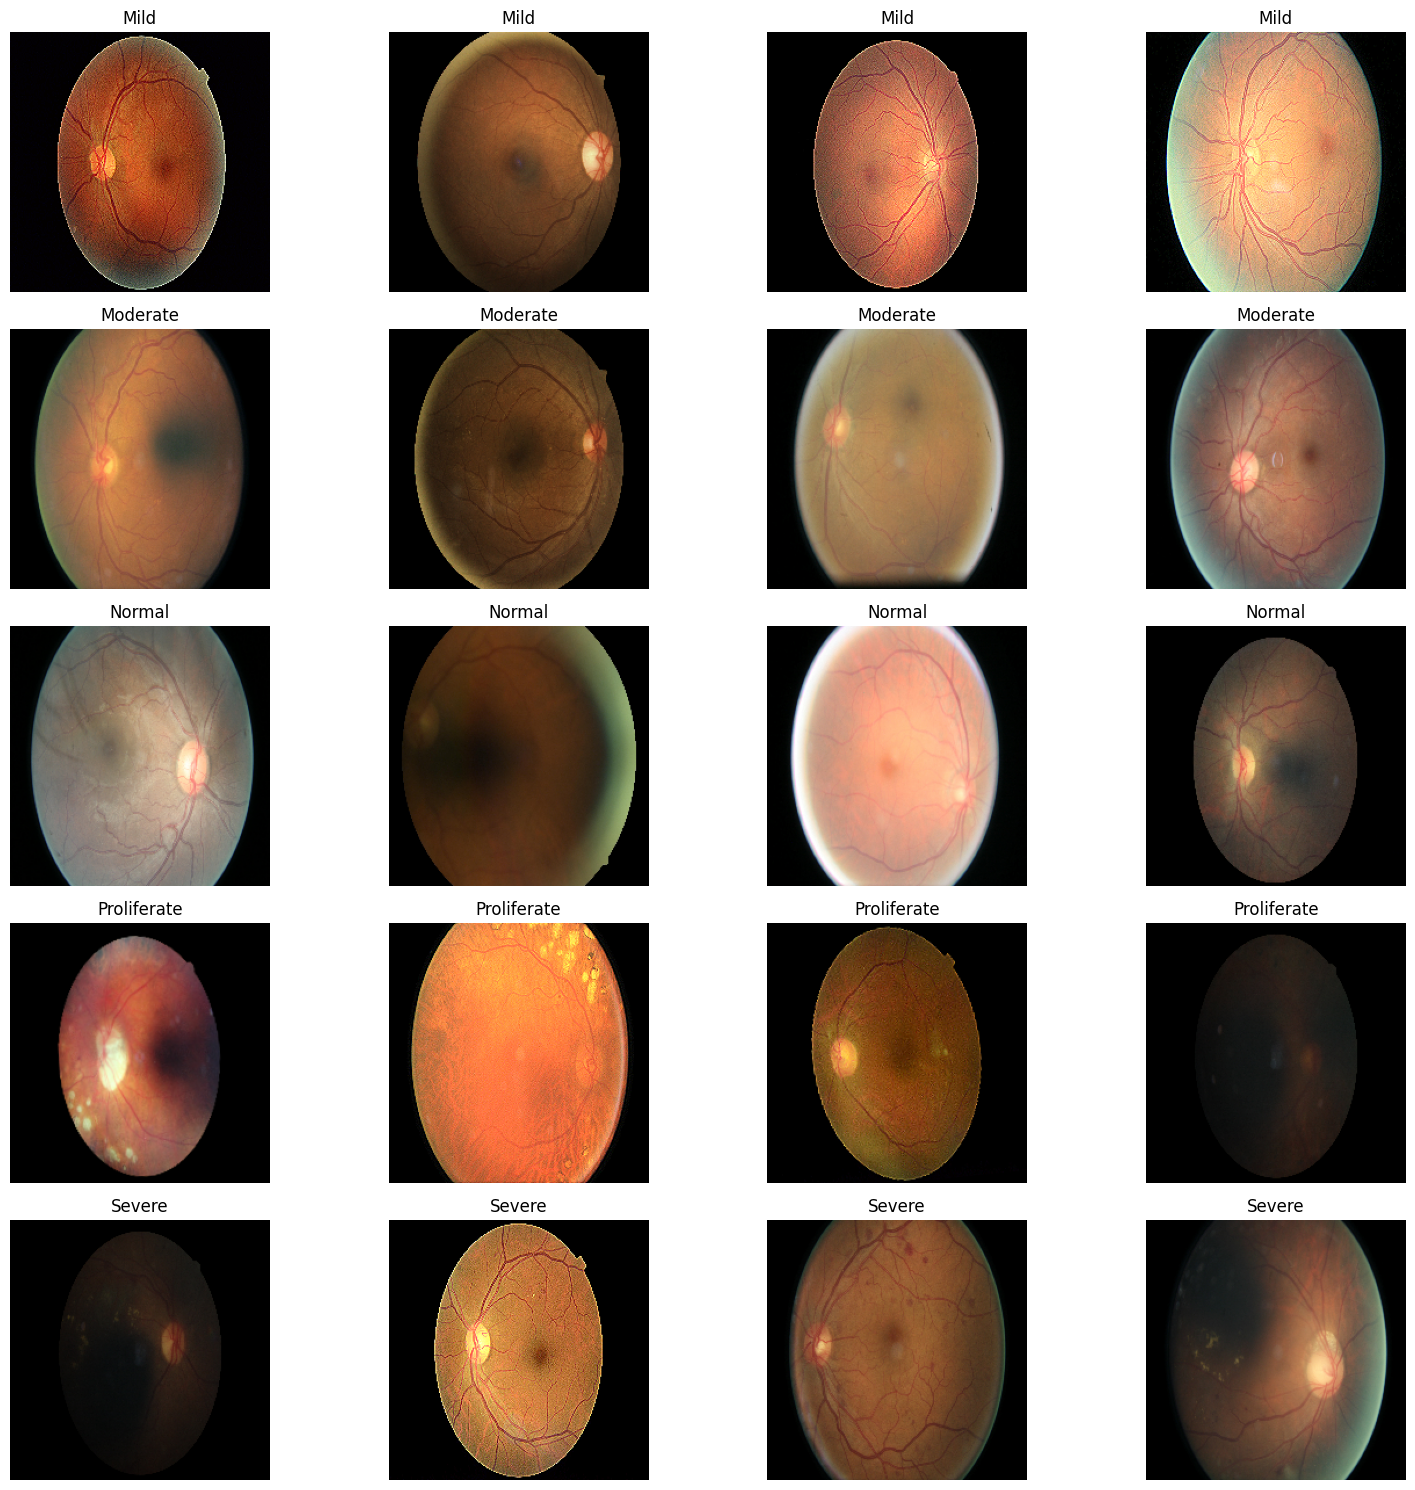

In [9]:
def show_class_samples(frame: pd.DataFrame, samples_per_class: int = 4):
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(4 * samples_per_class, 3 * len(classes)))
    axes = np.atleast_2d(axes)

    for row_index, label in enumerate(classes):
        label_rows = frame[frame['label'] == label].sample(samples_per_class, random_state=SEED)
        for col_index, (_, row) in enumerate(label_rows.iterrows()):
            image = tf.keras.utils.load_img(row['file_path'], target_size=IMG_SIZE)
            axes[row_index, col_index].imshow(image)
            axes[row_index, col_index].set_title(label)
            axes[row_index, col_index].axis('off')

    plt.tight_layout()
    plt.show()

show_class_samples(train_df)

In [10]:
train_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(train_df['label_id'].unique())),
    y=train_df['label_id'].values
)
class_weights = {index: weight for index, weight in enumerate(train_class_weights)}
class_weights

{0: 1.0606405394016014,
 1: 1.00676,
 2: 0.9637756078881868,
 3: 0.9680384615384615,
 4: 1.00676}

In [11]:
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name='augmentation')

def decode_image(file_path, label_id):
    image_bytes = tf.io.read_file(file_path)
    image = tf.image.decode_png(image_bytes, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, tf.one_hot(label_id, depth=len(classes))

def build_dataset(frame: pd.DataFrame, training: bool) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices((frame['file_path'].values, frame['label_id'].values))
    if training:
        shuffle_buffer = min(len(frame), SHUFFLE_BUFFER)
        dataset = dataset.shuffle(shuffle_buffer, seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(decode_image, num_parallel_calls=MAP_PARALLEL_CALLS)

    if training:
        dataset = dataset.map(
            lambda image, label: (augmenter(image, training=True), label),
            num_parallel_calls=MAP_PARALLEL_CALLS,
        )

    dataset = dataset.batch(BATCH_SIZE).prefetch(PREFETCH_BUFFER)
    return dataset

train_ds = build_dataset(train_df, training=True)
val_ds = build_dataset(val_df, training=False)
train_ds

2026-06-18 18:00:39.227110: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2026-06-18 18:00:39.227162: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-06-18 18:00:39.227171: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-06-18 18:00:39.227203: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-18 18:00:39.227212: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>

In [12]:
for images, labels in train_ds.take(1):
    print('Image batch shape:', images.shape)
    print('Label batch shape:', labels.shape)

Image batch shape: (8, 224, 224, 3)
Label batch shape: (8, 5)


2026-06-18 18:00:39.531883: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-06-18 18:00:39.594379: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
BACKBONE_BUILDERS = {
    'EfficientNetB0': tf.keras.applications.EfficientNetB0,
    'EfficientNetB3': tf.keras.applications.EfficientNetB3,
}

def build_compiled_model(selected_model_name: str):
    if selected_model_name not in BACKBONE_BUILDERS:
        raise ValueError(f'Unsupported MODEL_NAME: {selected_model_name}')

    tf.keras.backend.clear_session()
    preprocess_input = tf.keras.applications.efficientnet.preprocess_input
    base_model = BACKBONE_BUILDERS[selected_model_name](
        include_top=False,
        weights='imagenet',
        input_shape=IMG_SIZE + (3,),
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(len(classes), activation='softmax', dtype='float32')(x)
    built_model = tf.keras.Model(inputs, outputs, name=f'dr_{selected_model_name.lower()}')

    built_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
            tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy'),
        ],
    )
    return built_model, base_model

model_candidates = [MODEL_NAME] + [candidate for candidate in MODEL_FALLBACK_ORDER if candidate != MODEL_NAME]
build_errors = {}

for candidate in model_candidates:
    try:
        print(f'Attempting model build with {candidate}...')
        model, base_model = build_compiled_model(candidate)
        MODEL_NAME = candidate
        print(f'Using model: {MODEL_NAME}')
        break
    except (tf.errors.ResourceExhaustedError, tf.errors.InternalError) as exc:
        build_errors[candidate] = str(exc)
        print(f'Build failed for {candidate}. Trying next fallback...')
        tf.keras.backend.clear_session()
else:
    raise RuntimeError(f'All model build attempts failed: {build_errors}')

model.summary()

Attempting model build with EfficientNetB0...
Using model: EfficientNetB0


Model: "dr_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,096 (15.49 MB)

 Trainable params: 8,965 (35.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [14]:
checkpoint_path = ARTIFACTS_DIR / f'best_{MODEL_NAME.lower()}.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/4
3147/3147 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8006 - loss: 0.7584 - top2_accuracy: 0.9478
Epoch 1: val_accuracy improved from None to 0.24901, saving model to /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/best_efficientnetb0.keras
3147/3147 ━━━━━━━━━━━━━━━━━━━━ 145s 45ms/step - accuracy: 0.8097 - loss: 0.7223 - top2_accuracy: 0.9654 - val_accuracy: 0.2490 - val_loss: 3.1328 - val_top2_accuracy: 0.5995 - learning_rate: 0.0010
Epoch 2/4
3146/3147 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8282 - loss: 0.7005 - top2_accuracy: 0.9625
Epoch 2: val_accuracy did not improve from 0.24901
3147/3147 ━━━━━━━━━━━━━━━━━━━━ 138s 44ms/step - accuracy: 0.8249 - loss: 0.6654 - top2_accuracy: 0.9725 - val_accuracy: 0.2379 - val_loss: 2.9729 - val_top2_accuracy: 0.6312 - learning_rate: 0.0010
Epoch 3/4
3147/3147 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8324 - loss: 0.6695 - top2_accuracy: 0.9693
Epoch 3: val_accuracy did not improve from 0.24901
3147/31

In [15]:
base_model.trainable = True

fine_tune_last_layers = 25 if MODEL_NAME == 'EfficientNetB0' else 40
for layer in base_model.layers[:-fine_tune_last_layers]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy'),
    ],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=len(history_head.history['loss']),
    epochs=len(history_head.history['loss']) + EPOCHS_FINE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 5/10
3147/3147 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0595 - loss: 3.7137 - top2_accuracy: 0.2541
Epoch 5: val_accuracy improved from 0.26883 to 0.36796, saving model to /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/best_efficientnetb0.keras
3147/3147 ━━━━━━━━━━━━━━━━━━━━ 224s 69ms/step - accuracy: 0.2473 - loss: 2.5225 - top2_accuracy: 0.4872 - val_accuracy: 0.3680 - val_loss: 1.7619 - val_top2_accuracy: 0.6233 - learning_rate: 1.0000e-05
Epoch 6/10
3147/3147 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1706 - loss: 2.1963 - top2_accuracy: 0.3763
Epoch 6: val_accuracy improved from 0.36796 to 0.41237, saving model to /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/best_efficientnetb0.keras
3147/3147 ━━━━━━━━━━━━━━━━━━━━ 208s 66ms/step - accuracy: 0.3220 - loss: 1.7341 - top2_accuracy: 0.5340 - val_accuracy: 0.4124 - val_loss: 1.5136 - val_top2_accuracy: 0.6178 - learning_rate: 1.0000e-05
Epoch 7/10
3147/3147 ━━━━━━━━━━━━━━━━━━━━ 0s 6

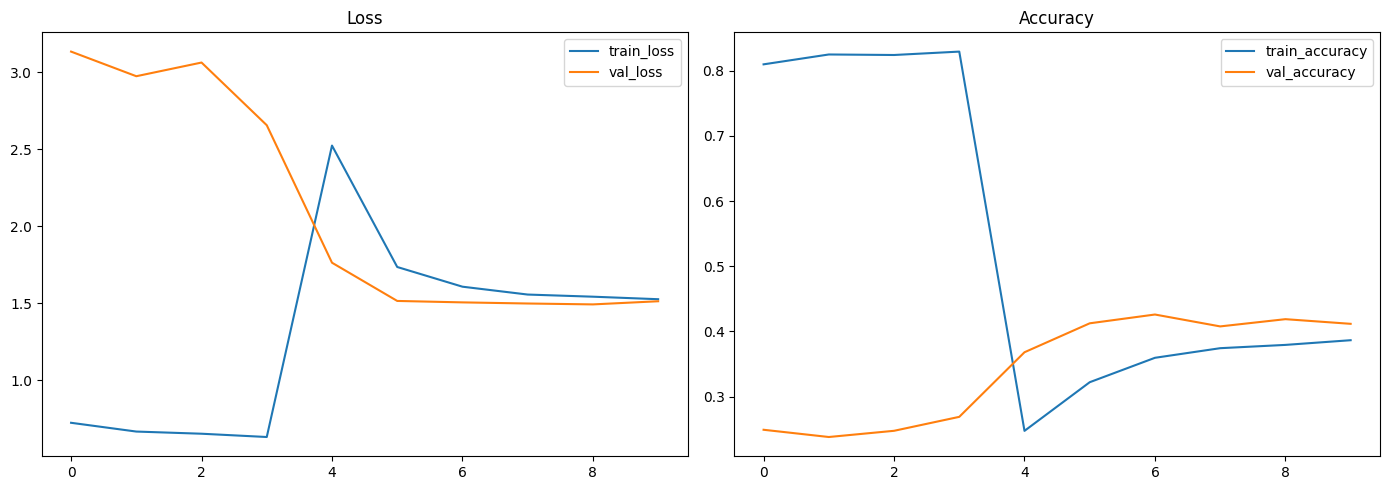

In [16]:
def merge_histories(*histories):
    merged = {}
    for history in histories:
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

history_all = merge_histories(history_head, history_fine)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_all['loss'], label='train_loss')
axes[0].plot(history_all['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_all['accuracy'], label='train_accuracy')
axes[1].plot(history_all['val_accuracy'], label='val_accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
best_model = tf.keras.models.load_model(checkpoint_path)
val_probabilities = best_model.predict(val_ds, verbose=1)
val_predictions = np.argmax(val_probabilities, axis=1)
val_true = val_df['label_id'].to_numpy()

# One-hot truth for probability-based metrics.
y_true_onehot = tf.keras.utils.to_categorical(val_true, num_classes=len(classes))

def expected_calibration_error(probabilities, true_labels, n_bins=15):
    confidence = np.max(probabilities, axis=1)
    predictions = np.argmax(probabilities, axis=1)
    correct = (predictions == true_labels).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece_value = 0.0
    bin_rows = []

    for bin_start, bin_end in zip(bin_edges[:-1], bin_edges[1:]):
        if bin_end == 1.0:
            in_bin = (confidence >= bin_start) & (confidence <= bin_end)
        else:
            in_bin = (confidence >= bin_start) & (confidence < bin_end)
        prop = np.mean(in_bin)
        if prop > 0:
            acc_bin = float(np.mean(correct[in_bin]))
            conf_bin = float(np.mean(confidence[in_bin]))
            ece_value += abs(acc_bin - conf_bin) * prop
            bin_rows.append({
                'bin_start': float(bin_start),
                'bin_end': float(bin_end),
                'bin_mid': float((bin_start + bin_end) / 2.0),
                'bin_accuracy': acc_bin,
                'bin_confidence': conf_bin,
                'bin_fraction': float(prop),
            })

    return float(ece_value), pd.DataFrame(bin_rows)

# Threshold-independent and threshold-dependent metrics.
accuracy = accuracy_score(val_true, val_predictions)
balanced_acc = balanced_accuracy_score(val_true, val_predictions)
top2_acc = top_k_accuracy_score(val_true, val_probabilities, k=2, labels=np.arange(len(classes)))

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    val_true, val_predictions, average='macro', zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    val_true, val_predictions, average='weighted', zero_division=0
)
f1_micro = f1_score(val_true, val_predictions, average='micro', zero_division=0)

# Requested regression-style error metrics on class probabilities.
mse = mean_squared_error(y_true_onehot, val_probabilities)
rmse = float(np.sqrt(mse))
cross_entropy = log_loss(val_true, val_probabilities, labels=np.arange(len(classes)))

# Agreement/robustness metrics often used for clinical-style classifiers.
kappa = cohen_kappa_score(val_true, val_predictions)
mcc = matthews_corrcoef(val_true, val_predictions)

# Multi-class AUC/AP via one-vs-rest.
auc_macro_ovr = roc_auc_score(y_true_onehot, val_probabilities, average='macro', multi_class='ovr')
auc_weighted_ovr = roc_auc_score(y_true_onehot, val_probabilities, average='weighted', multi_class='ovr')
ap_macro = average_precision_score(y_true_onehot, val_probabilities, average='macro')
ap_weighted = average_precision_score(y_true_onehot, val_probabilities, average='weighted')

# Deterministic uncertainty quantification (UQ).
eps = 1e-12
val_confidence = np.max(val_probabilities, axis=1)
val_correct = (val_predictions == val_true).astype(np.float32)
sorted_probabilities = np.sort(val_probabilities, axis=1)
confidence_margin = sorted_probabilities[:, -1] - sorted_probabilities[:, -2]
predictive_entropy = -np.sum(val_probabilities * np.log(val_probabilities + eps), axis=1)
normalized_entropy = predictive_entropy / np.log(len(classes))

# Multiclass Brier score and ECE.
brier_score = float(np.mean(np.sum((val_probabilities - y_true_onehot) ** 2, axis=1)))
ece, calibration_df = expected_calibration_error(val_probabilities, val_true, n_bins=15)

# Risk-coverage curve and AURC (lower is better).
sort_index = np.argsort(-val_confidence)
sorted_correct = val_correct[sort_index]
coverage_curve = np.arange(1, len(sorted_correct) + 1) / len(sorted_correct)
risk_curve = 1.0 - (np.cumsum(sorted_correct) / np.arange(1, len(sorted_correct) + 1))
aurc = float(np.trapz(risk_curve, coverage_curve))

# Temperature scaling calibration search on validation probabilities.
temperature_grid = np.linspace(0.5, 3.0, 51)
best_temperature = 1.0
best_temp_nll = float('inf')

for temp in temperature_grid:
    probs_temp = np.power(val_probabilities + eps, 1.0 / temp)
    probs_temp = probs_temp / np.sum(probs_temp, axis=1, keepdims=True)
    nll_temp = log_loss(val_true, probs_temp, labels=np.arange(len(classes)))
    if nll_temp < best_temp_nll:
        best_temp_nll = float(nll_temp)
        best_temperature = float(temp)

val_probabilities_temp = np.power(val_probabilities + eps, 1.0 / best_temperature)
val_probabilities_temp = val_probabilities_temp / np.sum(val_probabilities_temp, axis=1, keepdims=True)
val_predictions_temp = np.argmax(val_probabilities_temp, axis=1)
val_confidence_temp = np.max(val_probabilities_temp, axis=1)
val_correct_temp = (val_predictions_temp == val_true).astype(np.float32)

predictive_entropy_temp = -np.sum(val_probabilities_temp * np.log(val_probabilities_temp + eps), axis=1)
normalized_entropy_temp = predictive_entropy_temp / np.log(len(classes))
brier_score_temp = float(np.mean(np.sum((val_probabilities_temp - y_true_onehot) ** 2, axis=1)))
ece_temp, calibration_temp_df = expected_calibration_error(val_probabilities_temp, val_true, n_bins=15)

sort_index_temp = np.argsort(-val_confidence_temp)
sorted_correct_temp = val_correct_temp[sort_index_temp]
coverage_curve_temp = np.arange(1, len(sorted_correct_temp) + 1) / len(sorted_correct_temp)
risk_curve_temp = 1.0 - (np.cumsum(sorted_correct_temp) / np.arange(1, len(sorted_correct_temp) + 1))
aurc_temp = float(np.trapz(risk_curve_temp, coverage_curve_temp))

temperature_scaling_df = pd.DataFrame([
    {'metric': 'selected_temperature', 'value': best_temperature},
    {'metric': 'nll_pre', 'value': cross_entropy},
    {'metric': 'nll_post', 'value': best_temp_nll},
    {'metric': 'ece_pre', 'value': ece},
    {'metric': 'ece_post', 'value': ece_temp},
    {'metric': 'brier_pre', 'value': brier_score},
    {'metric': 'brier_post', 'value': brier_score_temp},
    {'metric': 'aurc_pre', 'value': aurc},
    {'metric': 'aurc_post', 'value': aurc_temp},
])

metrics_df = pd.DataFrame([
    {'metric': 'accuracy', 'value': accuracy},
    {'metric': 'balanced_accuracy', 'value': balanced_acc},
    {'metric': 'top2_accuracy', 'value': top2_acc},
    {'metric': 'precision_macro', 'value': precision_macro},
    {'metric': 'recall_macro', 'value': recall_macro},
    {'metric': 'f1_macro', 'value': f1_macro},
    {'metric': 'f1_micro', 'value': f1_micro},
    {'metric': 'precision_weighted', 'value': precision_weighted},
    {'metric': 'recall_weighted', 'value': recall_weighted},
    {'metric': 'f1_weighted', 'value': f1_weighted},
    {'metric': 'mse', 'value': mse},
    {'metric': 'rmse', 'value': rmse},
    {'metric': 'cross_entropy_log_loss', 'value': cross_entropy},
    {'metric': 'brier_score_multiclass', 'value': brier_score},
    {'metric': 'expected_calibration_error', 'value': ece},
    {'metric': 'aurc_risk_coverage', 'value': aurc},
    {'metric': 'temp_scaled_cross_entropy_log_loss', 'value': best_temp_nll},
    {'metric': 'temp_scaled_brier_score_multiclass', 'value': brier_score_temp},
    {'metric': 'temp_scaled_expected_calibration_error', 'value': ece_temp},
    {'metric': 'temp_scaled_aurc_risk_coverage', 'value': aurc_temp},
    {'metric': 'selected_temperature', 'value': best_temperature},
    {'metric': 'mean_predictive_entropy', 'value': float(np.mean(predictive_entropy))},
    {'metric': 'mean_normalized_entropy', 'value': float(np.mean(normalized_entropy))},
    {'metric': 'mean_confidence_margin', 'value': float(np.mean(confidence_margin))},
    {'metric': 'cohen_kappa', 'value': kappa},
    {'metric': 'matthews_corrcoef', 'value': mcc},
    {'metric': 'auc_macro_ovr', 'value': auc_macro_ovr},
    {'metric': 'auc_weighted_ovr', 'value': auc_weighted_ovr},
    {'metric': 'average_precision_macro', 'value': ap_macro},
    {'metric': 'average_precision_weighted', 'value': ap_weighted},
])

uq_summary_df = pd.DataFrame([
    {'metric': 'brier_score_multiclass', 'value': brier_score},
    {'metric': 'expected_calibration_error', 'value': ece},
    {'metric': 'aurc_risk_coverage', 'value': aurc},
    {'metric': 'temp_scaled_brier_score_multiclass', 'value': brier_score_temp},
    {'metric': 'temp_scaled_expected_calibration_error', 'value': ece_temp},
    {'metric': 'temp_scaled_aurc_risk_coverage', 'value': aurc_temp},
    {'metric': 'selected_temperature', 'value': best_temperature},
    {'metric': 'mean_predictive_entropy', 'value': float(np.mean(predictive_entropy))},
    {'metric': 'mean_normalized_entropy', 'value': float(np.mean(normalized_entropy))},
    {'metric': 'mean_confidence', 'value': float(np.mean(val_confidence))},
    {'metric': 'mean_confidence_margin', 'value': float(np.mean(confidence_margin))},
])

print(metrics_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()
print('Temperature scaling summary:')
print(temperature_scaling_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()
print(classification_report(val_true, val_predictions, target_names=classes, digits=4, zero_division=0))

per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
    val_true, val_predictions, labels=np.arange(len(classes)), average=None, zero_division=0
)
per_class_df = pd.DataFrame({
    'class': classes,
    'precision': per_class_precision,
    'recall': per_class_recall,
    'f1': per_class_f1,
    'support': per_class_support,
})
per_class_df

158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step
                                metric  value
                              accuracy 0.4259
                     balanced_accuracy 0.3908
                         top2_accuracy 0.6067
                       precision_macro 0.4479
                          recall_macro 0.3908
                              f1_macro 0.3350
                              f1_micro 0.4259
                    precision_weighted 0.4268
                       recall_weighted 0.4259
                           f1_weighted 0.3618
                                   mse 0.1464
                                  rmse 0.3827
                cross_entropy_log_loss 1.4876
                brier_score_multiclass 0.7321
            expected_calibration_error 0.1341
                    aurc_risk_coverage 0.4210
    temp_scaled_cross_entropy_log_loss 1.3961
    temp_scaled_brier_score_multiclass 0.7056
temp_scaled_expected_calibration_error 0.0403
        temp_scaled_aurc_risk_coverage

,class,precision,recall,f1,support
0,Mild,0.692308,0.064286,0.117647,140
1,Moderate,0.200000,0.003425,0.006734,292
2,Normal,0.412556,0.623729,0.496626,295
3,Proliferate,0.667692,0.733108,0.698873,296
4,Severe,0.266949,0.529412,0.354930,238


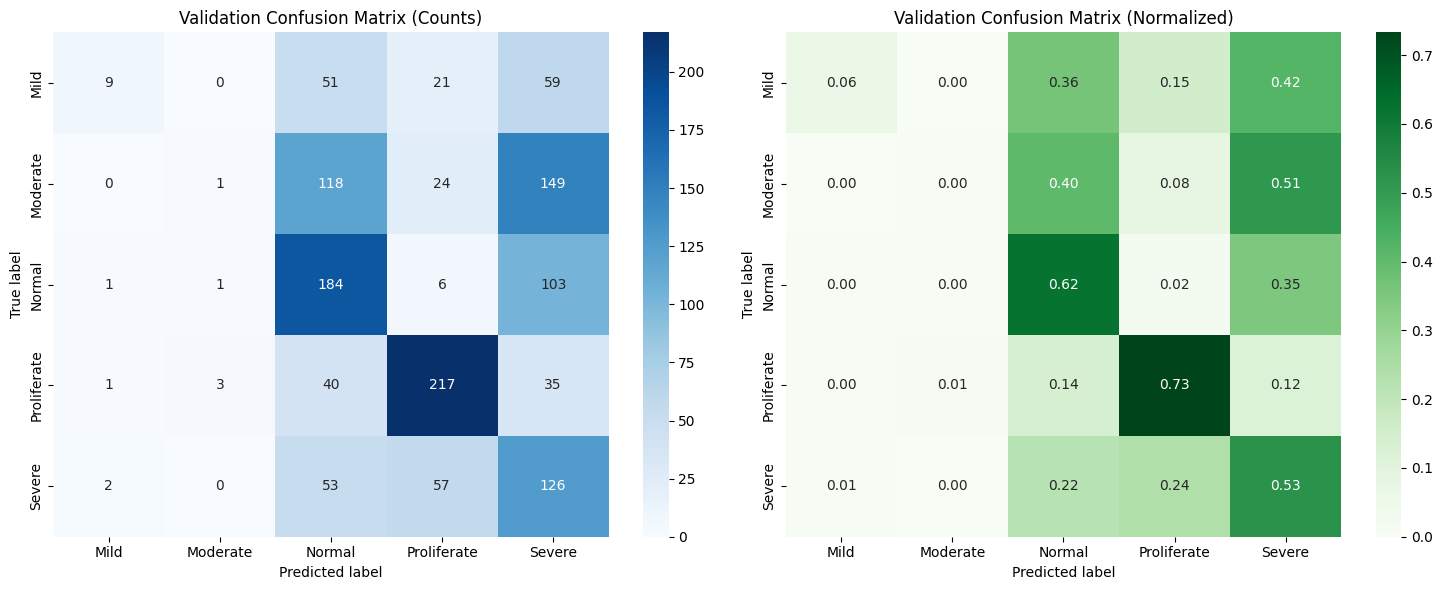

In [18]:
cm = confusion_matrix(val_true, val_predictions, labels=np.arange(len(classes)))
cm_normalized = confusion_matrix(
    val_true, val_predictions, labels=np.arange(len(classes)), normalize='true'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0]
)
axes[0].set_title('Validation Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

sns.heatmap(
    cm_normalized, annot=True, fmt='.2f', cmap='Greens', xticklabels=classes, yticklabels=classes, ax=axes[1]
)
axes[1].set_title('Validation Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.show()

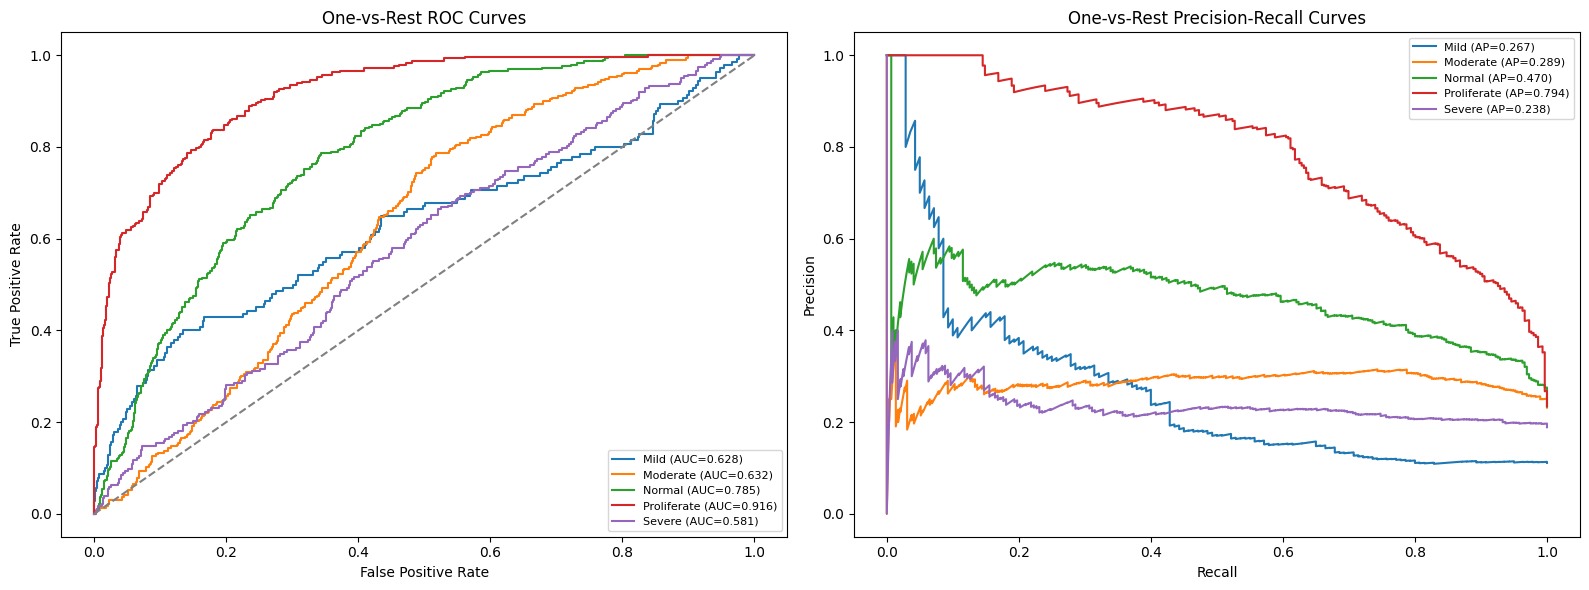

In [19]:
# One-vs-rest ROC and Precision-Recall curves.
n_classes = len(classes)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for class_index, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, class_index], val_probabilities[:, class_index])
    pr, rc, _ = precision_recall_curve(y_true_onehot[:, class_index], val_probabilities[:, class_index])

    class_auc = auc(fpr, tpr)
    class_ap = average_precision_score(y_true_onehot[:, class_index], val_probabilities[:, class_index])

    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC={class_auc:.3f})')
    axes[1].plot(rc, pr, label=f'{class_name} (AP={class_ap:.3f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('One-vs-Rest ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

axes[1].set_title('One-vs-Rest Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

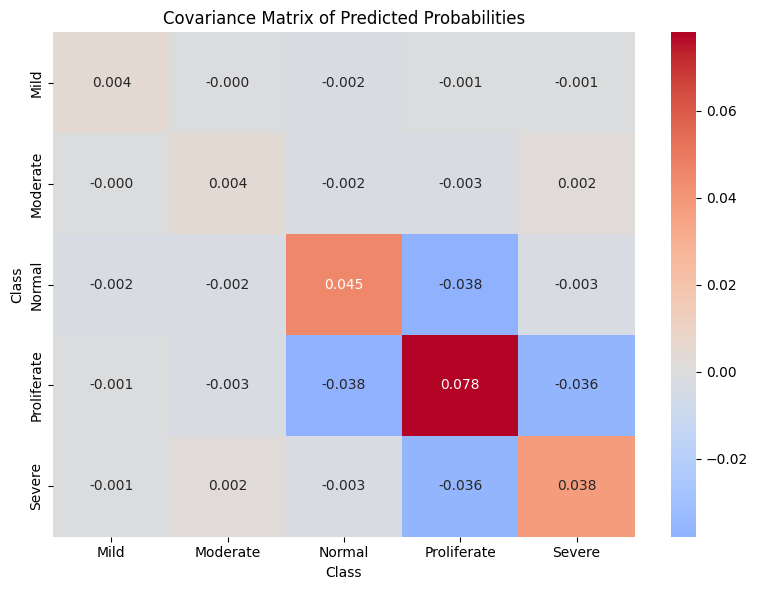

In [20]:
# Covariance matrix of predicted class probabilities.
probability_covariance = np.cov(val_probabilities, rowvar=False)
plt.figure(figsize=(8, 6))
sns.heatmap(
    probability_covariance,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    xticklabels=classes,
    yticklabels=classes,
    center=0,
    )
plt.title('Covariance Matrix of Predicted Probabilities')
plt.xlabel('Class')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

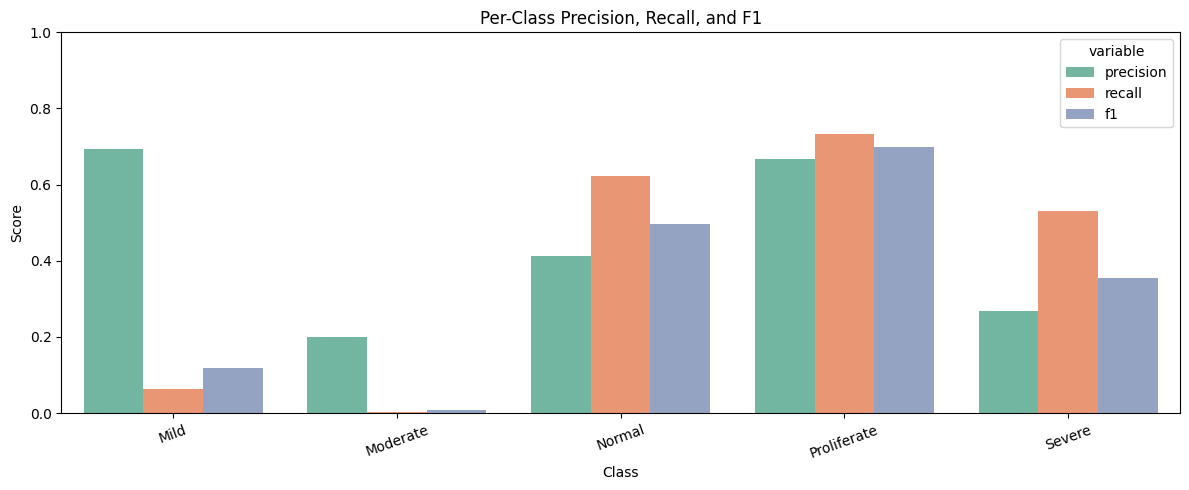

In [21]:
# Per-class quality bars.
plot_df = per_class_df.melt(id_vars=['class', 'support'], value_vars=['precision', 'recall', 'f1'])
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x='class', y='value', hue='variable', palette='Set2')
plt.ylim(0, 1.0)
plt.title('Per-Class Precision, Recall, and F1')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

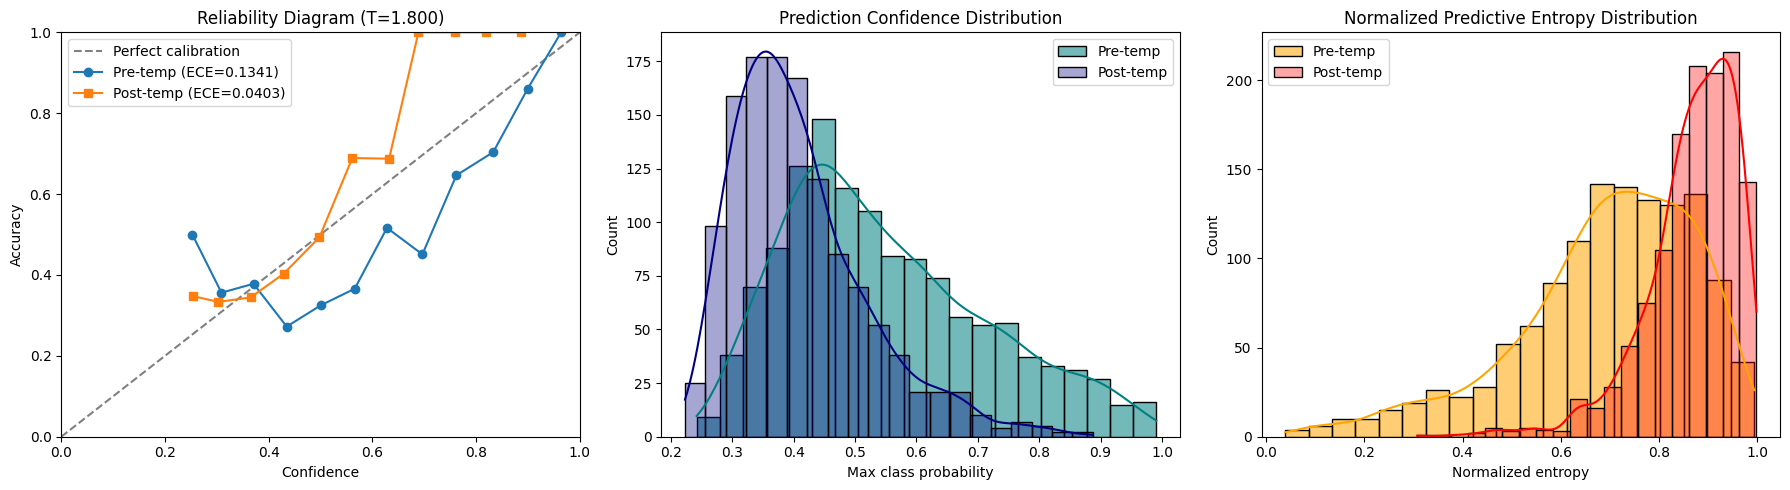

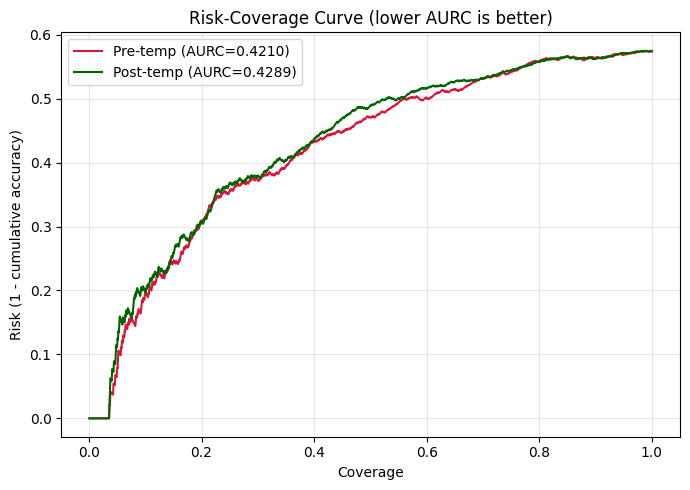

2026-06-18 18:32:48.615359: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 18:33:18.042836: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 18:33:47.093396: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 18:34:16.306210: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 18:34:45.312931: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 18:35:14.646380: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 18:35:44.171300: W tensorflow/core/framework/local_rendezvous.cc:404] L

,metric,value
0,mc_passes,10.000000
1,mc_mean_predictive_entropy,1.386071
2,mc_mean_mutual_information,0.114180
3,mc_mean_variation_ratio,0.290008


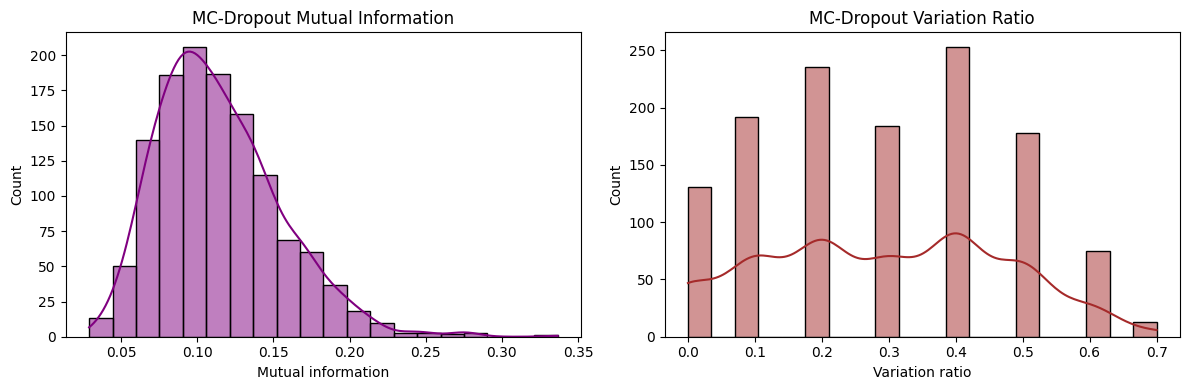

In [22]:
# Uncertainty quantification (UQ) visuals and optional MC-dropout epistemic UQ.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reliability diagram with pre/post temperature-scaling calibration.
if not calibration_df.empty:
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    axes[0].plot(
        calibration_df['bin_confidence'],
        calibration_df['bin_accuracy'],
        marker='o',
        label=f'Pre-temp (ECE={ece:.4f})',
    )
    if 'calibration_temp_df' in globals() and not calibration_temp_df.empty:
        axes[0].plot(
            calibration_temp_df['bin_confidence'],
            calibration_temp_df['bin_accuracy'],
            marker='s',
            label=f'Post-temp (ECE={ece_temp:.4f})',
        )
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_title(f'Reliability Diagram (T={best_temperature:.3f})')
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No calibration bins available', ha='center', va='center')
    axes[0].set_title('Reliability Diagram')

# Confidence and entropy distributions (pre/post calibration).
sns.histplot(val_confidence, bins=20, kde=True, ax=axes[1], color='teal', alpha=0.55, label='Pre-temp')
sns.histplot(val_confidence_temp, bins=20, kde=True, ax=axes[1], color='navy', alpha=0.35, label='Post-temp')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].set_xlabel('Max class probability')
axes[1].set_ylabel('Count')
axes[1].legend()

sns.histplot(normalized_entropy, bins=20, kde=True, ax=axes[2], color='orange', alpha=0.55, label='Pre-temp')
sns.histplot(normalized_entropy_temp, bins=20, kde=True, ax=axes[2], color='red', alpha=0.35, label='Post-temp')
axes[2].set_title('Normalized Predictive Entropy Distribution')
axes[2].set_xlabel('Normalized entropy')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

# Risk-coverage curves for selective prediction.
plt.figure(figsize=(7, 5))
plt.plot(coverage_curve, risk_curve, color='crimson', label=f'Pre-temp (AURC={aurc:.4f})')
plt.plot(coverage_curve_temp, risk_curve_temp, color='darkgreen', label=f'Post-temp (AURC={aurc_temp:.4f})')
plt.title('Risk-Coverage Curve (lower AURC is better)')
plt.xlabel('Coverage')
plt.ylabel('Risk (1 - cumulative accuracy)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional MC-dropout uncertainty estimates (epistemic proxy).
MC_DROPOUT_PASSES = 10
mc_dropout_enabled = True
if mc_dropout_enabled:
    mc_probs = []
    for _ in range(MC_DROPOUT_PASSES):
        pass_outputs = []
        for images, _ in val_ds:
            pass_outputs.append(best_model(images, training=True).numpy())
        mc_probs.append(np.concatenate(pass_outputs, axis=0))

    mc_probs = np.stack(mc_probs, axis=0)  # [T, N, C]
    mc_mean_probs = mc_probs.mean(axis=0)
    mc_pred_entropy = -np.sum(mc_mean_probs * np.log(mc_mean_probs + 1e-12), axis=1)
    mc_expected_entropy = -np.mean(np.sum(mc_probs * np.log(mc_probs + 1e-12), axis=2), axis=0)
    mc_mutual_information = mc_pred_entropy - mc_expected_entropy

    # Variation ratio based on class vote agreement across MC samples.
    mc_pred_classes = np.argmax(mc_probs, axis=2)  # [T, N]
    vote_counts = np.zeros((mc_pred_classes.shape[1], len(classes)), dtype=np.int32)
    for class_index in range(len(classes)):
        vote_counts[:, class_index] = np.sum(mc_pred_classes == class_index, axis=0)
    variation_ratio = 1.0 - (np.max(vote_counts, axis=1) / MC_DROPOUT_PASSES)

    uq_mc_df = pd.DataFrame([
        {'metric': 'mc_passes', 'value': float(MC_DROPOUT_PASSES)},
        {'metric': 'mc_mean_predictive_entropy', 'value': float(np.mean(mc_pred_entropy))},
        {'metric': 'mc_mean_mutual_information', 'value': float(np.mean(mc_mutual_information))},
        {'metric': 'mc_mean_variation_ratio', 'value': float(np.mean(variation_ratio))},
    ])
    display(uq_mc_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(mc_mutual_information, bins=20, kde=True, ax=axes[0], color='purple')
    axes[0].set_title('MC-Dropout Mutual Information')
    axes[0].set_xlabel('Mutual information')

    sns.histplot(variation_ratio, bins=20, kde=True, ax=axes[1], color='brown')
    axes[1].set_title('MC-Dropout Variation Ratio')
    axes[1].set_xlabel('Variation ratio')

    plt.tight_layout()
    plt.show()

,metric,pre,post,delta_post_minus_pre
0,temperature,1.000000,1.800000,0.800000
1,accuracy,0.425852,0.425852,0.000000
2,ece,0.134073,0.040277,-0.093796
3,nll_log_loss,1.487618,1.396087,-0.091531
4,brier_score_multiclass,0.732149,0.705633,-0.026516


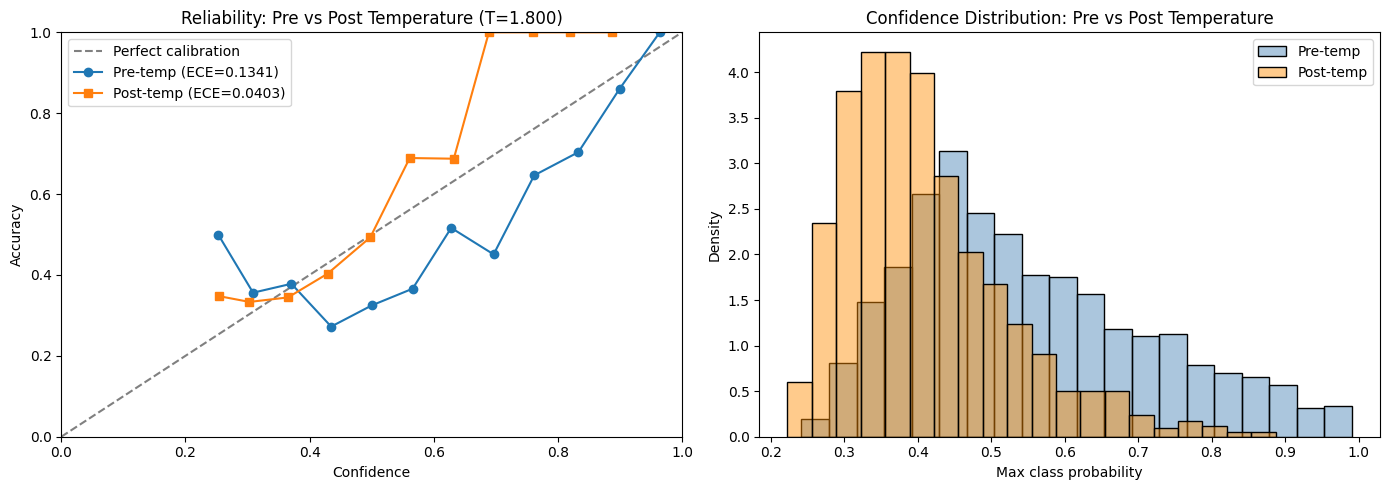

Saved temperature-scaling artifacts:
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/temperature_scaling_summary.csv
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/calibration_bins_pre_temperature.csv
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/calibration_bins_post_temperature.csv
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/temperature_scaling_reliability.png


In [23]:
# Temperature scaling calibration (post-hoc) with pre/post UQ comparison.
required_for_temp = ['val_probabilities', 'val_true', 'y_true_onehot', 'classes']
missing_for_temp = [name for name in required_for_temp if name not in globals()]
if missing_for_temp:
    raise RuntimeError(
        'Run the main evaluation cell first. Missing: ' + ', '.join(missing_for_temp)
    )

def stable_softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

def calibration_bins(confidence, correct, n_bins=15):
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    for start, end in zip(edges[:-1], edges[1:]):
        if end == 1.0:
            in_bin = (confidence >= start) & (confidence <= end)
        else:
            in_bin = (confidence >= start) & (confidence < end)
        frac = np.mean(in_bin)
        if frac > 0:
            rows.append({
                'bin_start': float(start),
                'bin_end': float(end),
                'bin_mid': float((start + end) / 2.0),
                'bin_accuracy': float(np.mean(correct[in_bin])),
                'bin_confidence': float(np.mean(confidence[in_bin])),
                'bin_fraction': float(frac),
            })
    return pd.DataFrame(rows)

def expected_calibration_error(confidence, correct, n_bins=15):
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece_value = 0.0
    for start, end in zip(edges[:-1], edges[1:]):
        if end == 1.0:
            in_bin = (confidence >= start) & (confidence <= end)
        else:
            in_bin = (confidence >= start) & (confidence < end)
        frac = np.mean(in_bin)
        if frac > 0:
            acc_bin = float(np.mean(correct[in_bin]))
            conf_bin = float(np.mean(confidence[in_bin]))
            ece_value += abs(acc_bin - conf_bin) * frac
    return float(ece_value)

eps = 1e-12
raw_logits = np.log(np.clip(val_probabilities, eps, 1.0))

# Optimize temperature on validation NLL by grid search to avoid extra dependencies.
candidate_temperatures = np.concatenate([
    np.linspace(0.5, 3.0, 251),
    np.linspace(3.05, 8.0, 100),
])
best_temperature = 1.0
best_nll = np.inf

for temperature in candidate_temperatures:
    probs_t = stable_softmax(raw_logits / temperature)
    nll_t = log_loss(val_true, probs_t, labels=np.arange(len(classes)))
    if nll_t < best_nll:
        best_nll = float(nll_t)
        best_temperature = float(temperature)

val_probabilities_temp = stable_softmax(raw_logits / best_temperature)
val_predictions_temp = np.argmax(val_probabilities_temp, axis=1)
val_confidence_raw = np.max(val_probabilities, axis=1)
val_confidence_temp = np.max(val_probabilities_temp, axis=1)
val_correct_raw = (val_predictions == val_true).astype(np.float32)
val_correct_temp = (val_predictions_temp == val_true).astype(np.float32)

ece_raw = expected_calibration_error(val_confidence_raw, val_correct_raw, n_bins=15)
ece_temp = expected_calibration_error(val_confidence_temp, val_correct_temp, n_bins=15)
nll_raw = float(log_loss(val_true, val_probabilities, labels=np.arange(len(classes))))
nll_temp = float(log_loss(val_true, val_probabilities_temp, labels=np.arange(len(classes))))
brier_raw = float(np.mean(np.sum((val_probabilities - y_true_onehot) ** 2, axis=1)))
brier_temp = float(np.mean(np.sum((val_probabilities_temp - y_true_onehot) ** 2, axis=1)))
acc_raw = float(accuracy_score(val_true, val_predictions))
acc_temp = float(accuracy_score(val_true, val_predictions_temp))

temp_scaling_df = pd.DataFrame([
    {'metric': 'temperature', 'pre': 1.0, 'post': best_temperature},
    {'metric': 'accuracy', 'pre': acc_raw, 'post': acc_temp},
    {'metric': 'ece', 'pre': ece_raw, 'post': ece_temp},
    {'metric': 'nll_log_loss', 'pre': nll_raw, 'post': nll_temp},
    {'metric': 'brier_score_multiclass', 'pre': brier_raw, 'post': brier_temp},
])
temp_scaling_df['delta_post_minus_pre'] = temp_scaling_df['post'] - temp_scaling_df['pre']
display(temp_scaling_df)

# Optional merge into global metric tables for easier export.
if 'metrics_df' in globals():
    extra_rows = pd.DataFrame([
        {'metric': 'temperature_scaling_temperature', 'value': best_temperature},
        {'metric': 'expected_calibration_error_post_temperature', 'value': ece_temp},
        {'metric': 'cross_entropy_log_loss_post_temperature', 'value': nll_temp},
        {'metric': 'brier_score_multiclass_post_temperature', 'value': brier_temp},
    ])
    metrics_df = pd.concat([metrics_df, extra_rows], ignore_index=True)

if 'uq_summary_df' in globals():
    uq_extra = pd.DataFrame([
        {'metric': 'temperature_scaling_temperature', 'value': best_temperature},
        {'metric': 'ece_pre_temperature', 'value': ece_raw},
        {'metric': 'ece_post_temperature', 'value': ece_temp},
        {'metric': 'nll_pre_temperature', 'value': nll_raw},
        {'metric': 'nll_post_temperature', 'value': nll_temp},
    ])
    uq_summary_df = pd.concat([uq_summary_df, uq_extra], ignore_index=True)

calibration_df_raw = calibration_bins(val_confidence_raw, val_correct_raw, n_bins=15)
calibration_df_temp = calibration_bins(val_confidence_temp, val_correct_temp, n_bins=15)

# Plot reliability and confidence pre/post temperature scaling.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
if not calibration_df_raw.empty:
    axes[0].plot(
        calibration_df_raw['bin_confidence'],
        calibration_df_raw['bin_accuracy'],
        marker='o',
        label=f'Pre-temp (ECE={ece_raw:.4f})',
    )
if not calibration_df_temp.empty:
    axes[0].plot(
        calibration_df_temp['bin_confidence'],
        calibration_df_temp['bin_accuracy'],
        marker='s',
        label=f'Post-temp (ECE={ece_temp:.4f})',
    )
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_title(f'Reliability: Pre vs Post Temperature (T={best_temperature:.3f})')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

sns.histplot(val_confidence_raw, bins=20, stat='density', color='steelblue', alpha=0.45, label='Pre-temp', ax=axes[1])
sns.histplot(val_confidence_temp, bins=20, stat='density', color='darkorange', alpha=0.45, label='Post-temp', ax=axes[1])
axes[1].set_title('Confidence Distribution: Pre vs Post Temperature')
axes[1].set_xlabel('Max class probability')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# Save calibration artifacts now so run packaging can include them.
eval_dir = ARTIFACTS_DIR / 'eval'
eval_dir.mkdir(parents=True, exist_ok=True)
temp_scaling_df.to_csv(eval_dir / 'temperature_scaling_summary.csv', index=False)
calibration_df_raw.to_csv(eval_dir / 'calibration_bins_pre_temperature.csv', index=False)
calibration_df_temp.to_csv(eval_dir / 'calibration_bins_post_temperature.csv', index=False)
fig.savefig(eval_dir / 'temperature_scaling_reliability.png', dpi=180, bbox_inches='tight')

print('Saved temperature-scaling artifacts:')
print('-', eval_dir / 'temperature_scaling_summary.csv')
print('-', eval_dir / 'calibration_bins_pre_temperature.csv')
print('-', eval_dir / 'calibration_bins_post_temperature.csv')
print('-', eval_dir / 'temperature_scaling_reliability.png')

In [24]:
# Final report: decision-critical metrics pre vs post calibration in one view.
required_final = [
    'metrics_df', 'temperature_scaling_df', 'per_class_df', 'classes',
    'val_true', 'val_predictions', 'MODEL_NAME', 'best_temperature',
]
missing_final = [name for name in required_final if name not in globals()]
if missing_final:
    raise RuntimeError(
        'Run all evaluation cells first. Missing: ' + ', '.join(missing_final)
    )

# Pull scalar metrics cleanly from metrics_df.
def _get(name, default=None):
    rows = metrics_df[metrics_df['metric'] == name]['value']
    return float(rows.iloc[0]) if len(rows) else default

# Summarise all key metrics in three groups.
classification_summary = pd.DataFrame({
    'metric': [
        'accuracy', 'balanced_accuracy', 'top2_accuracy',
        'f1_macro', 'f1_weighted', 'auc_macro_ovr', 'cohen_kappa', 'matthews_corrcoef',
    ],
    'value': [
        _get('accuracy'),
        _get('balanced_accuracy'),
        _get('top2_accuracy'),
        _get('f1_macro'),
        _get('f1_weighted'),
        _get('auc_macro_ovr'),
        _get('cohen_kappa'),
        _get('matthews_corrcoef'),
    ],
})

# Pre/post calibration comparison.
pre_ece = _get('expected_calibration_error')
post_ece = _get('temp_scaled_expected_calibration_error')
pre_nll = _get('cross_entropy_log_loss')
post_nll = _get('temp_scaled_cross_entropy_log_loss')
pre_brier = _get('brier_score_multiclass')
post_brier = _get('temp_scaled_brier_score_multiclass')
pre_aurc = _get('aurc_risk_coverage')
post_aurc = _get('temp_scaled_aurc_risk_coverage')

calibration_summary = pd.DataFrame([
    {'metric': 'ece',           'pre': pre_ece,    'post': post_ece,    'improved': post_ece < pre_ece if None not in (pre_ece, post_ece) else None},
    {'metric': 'nll_log_loss',  'pre': pre_nll,    'post': post_nll,    'improved': post_nll < pre_nll if None not in (pre_nll, post_nll) else None},
    {'metric': 'brier_score',   'pre': pre_brier,  'post': post_brier,  'improved': post_brier < pre_brier if None not in (pre_brier, post_brier) else None},
    {'metric': 'aurc',          'pre': pre_aurc,   'post': post_aurc,   'improved': post_aurc < pre_aurc if None not in (pre_aurc, post_aurc) else None},
])
calibration_summary['delta'] = calibration_summary['post'] - calibration_summary['pre']

print('=' * 65)
print(f'  FINAL REPORT   |   Model: {MODEL_NAME}   |   Temperature: {best_temperature:.3f}')
print('=' * 65)
print()
print('─── Classification Metrics ──────────────────────────────────')
print(classification_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()
print('─── Calibration: Pre vs Post Temperature Scaling ────────────')
print(calibration_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))
print()
print('─── Per-Class F1 ────────────────────────────────────────────')
print(per_class_df[['class', 'f1', 'precision', 'recall', 'support']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()

# Print a two-sentence plain-language calibration verdict.
if post_ece is not None and pre_ece is not None:
    delta_ece_pct = (post_ece - pre_ece) / (pre_ece + 1e-12) * 100
    direction = 'improved' if post_ece < pre_ece else 'worsened'
    print(f'Calibration {direction} after temperature scaling (T={best_temperature:.3f}).')
    print(f'ECE changed by {delta_ece_pct:+.1f}% ({pre_ece:.4f} → {post_ece:.4f}).')

# Save to eval dir.
eval_dir = ARTIFACTS_DIR / 'eval'
eval_dir.mkdir(parents=True, exist_ok=True)
classification_summary.to_csv(eval_dir / 'final_report_classification.csv', index=False)
calibration_summary.to_csv(eval_dir / 'final_report_calibration.csv', index=False)
print()
print('Saved final report to:')
print('-', eval_dir / 'final_report_classification.csv')
print('-', eval_dir / 'final_report_calibration.csv')

  FINAL REPORT   |   Model: EfficientNetB0   |   Temperature: 1.800

─── Classification Metrics ──────────────────────────────────
           metric  value
         accuracy 0.4259
balanced_accuracy 0.3908
    top2_accuracy 0.6067
         f1_macro 0.3350
      f1_weighted 0.3618
    auc_macro_ovr 0.7084
      cohen_kappa 0.2677
matthews_corrcoef 0.2891

─── Calibration: Pre vs Post Temperature Scaling ────────────
      metric    pre   post  improved   delta
         ece 0.1341 0.0403      True -0.0938
nll_log_loss 1.4876 1.3961      True -0.0915
 brier_score 0.7321 0.7056      True -0.0265
        aurc 0.4210 0.4289     False  0.0079

─── Per-Class F1 ────────────────────────────────────────────
      class     f1  precision  recall  support
       Mild 0.1176     0.6923  0.0643      140
   Moderate 0.0067     0.2000  0.0034      292
     Normal 0.4966     0.4126  0.6237      295
Proliferate 0.6989     0.6677  0.7331      296
     Severe 0.3549     0.2669  0.5294      238

Calibratio

## Final Report

Key decision metrics at a glance — before and after temperature scaling calibration.

Saved metrics to:
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/metrics_summary.csv
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/per_class_metrics.csv
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/uq_summary_metrics.csv
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/temperature_scaling_summary.csv
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/calibration_bins_pre_temp.csv
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/calibration_bins_post_temp.csv


,metric,value
0,accuracy,0.425852
1,auc_macro_ovr,0.708368
2,auc_weighted_ovr,0.724352
3,aurc_risk_coverage,0.421012
4,average_precision_macro,0.411442
5,average_precision_weighted,0.437594
6,balanced_accuracy,0.390792
7,brier_score_multiclass,0.732149
8,brier_score_multiclass_post_temperature,0.705633
9,cohen_kappa,0.267716


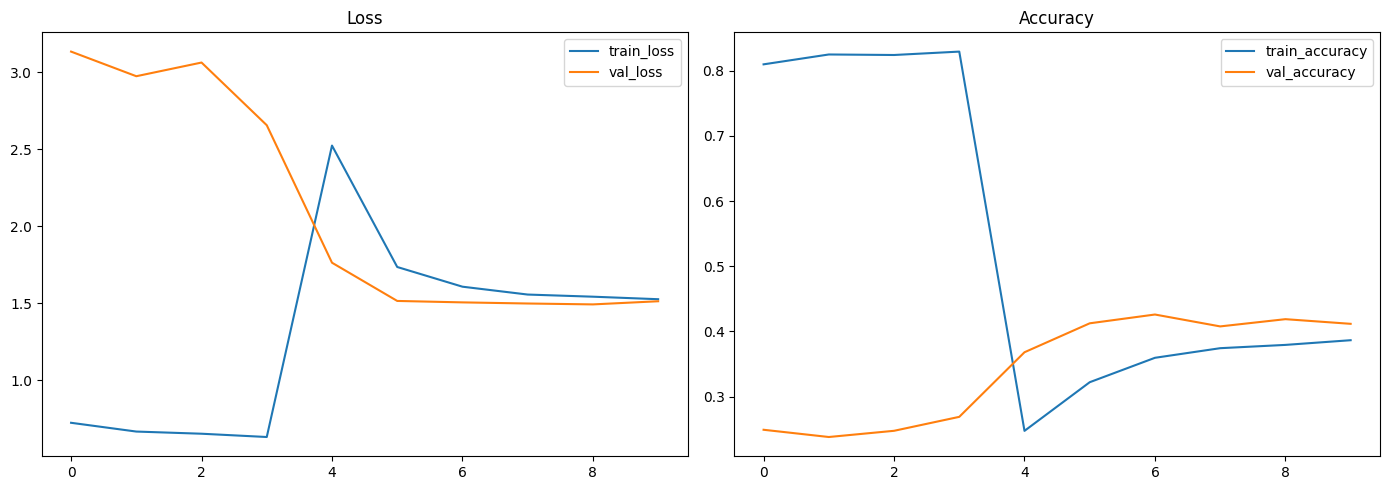

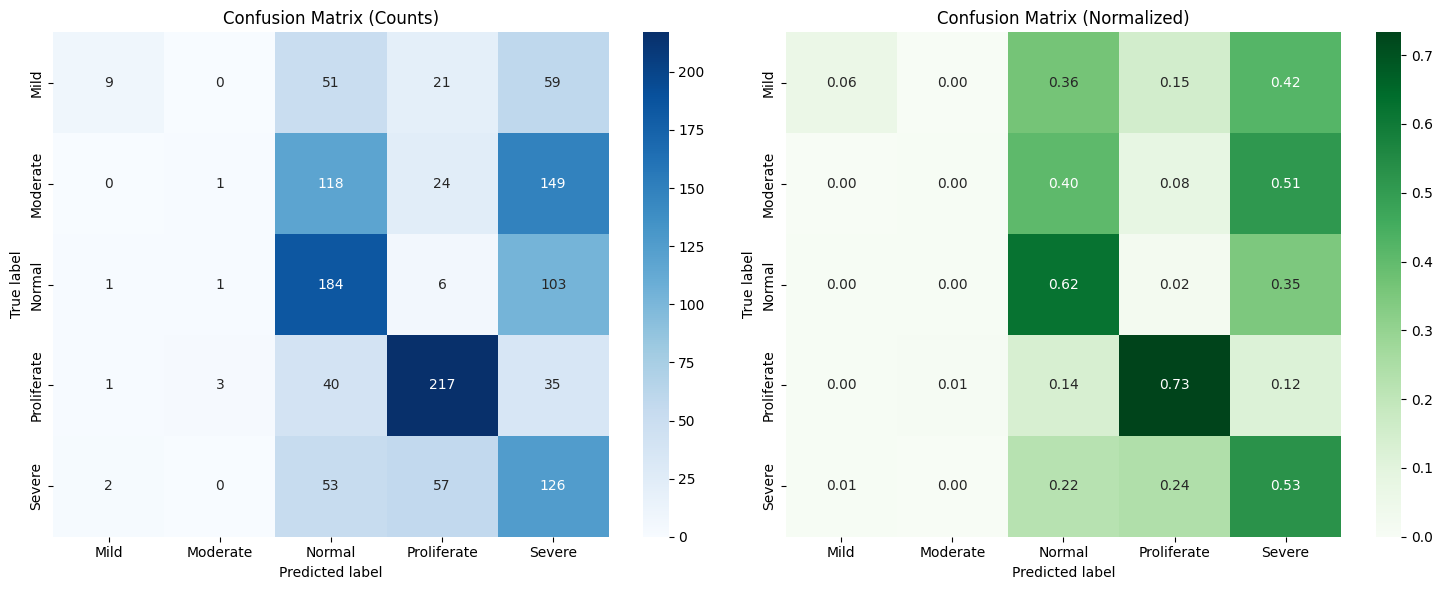

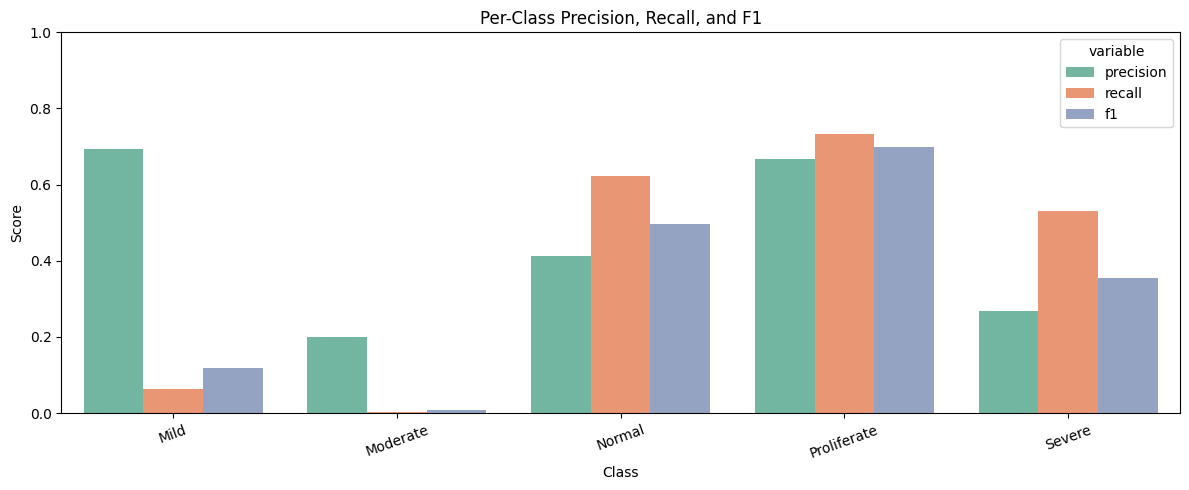

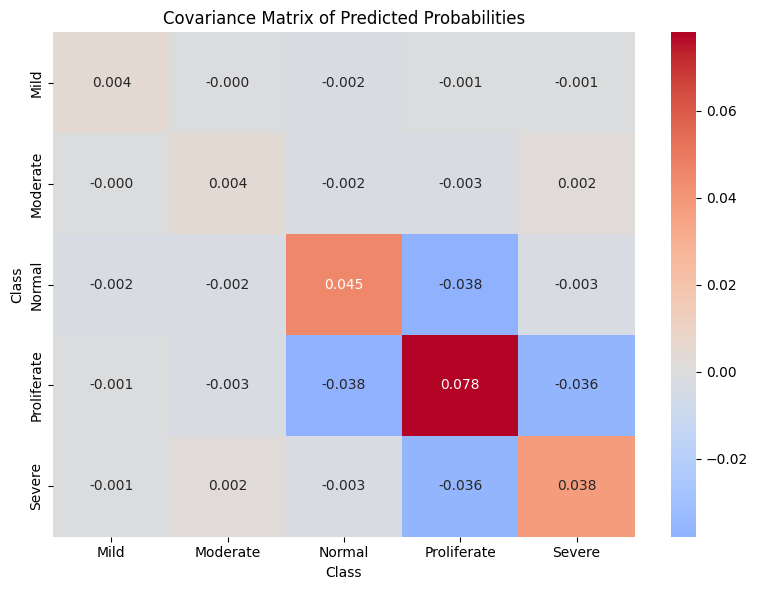

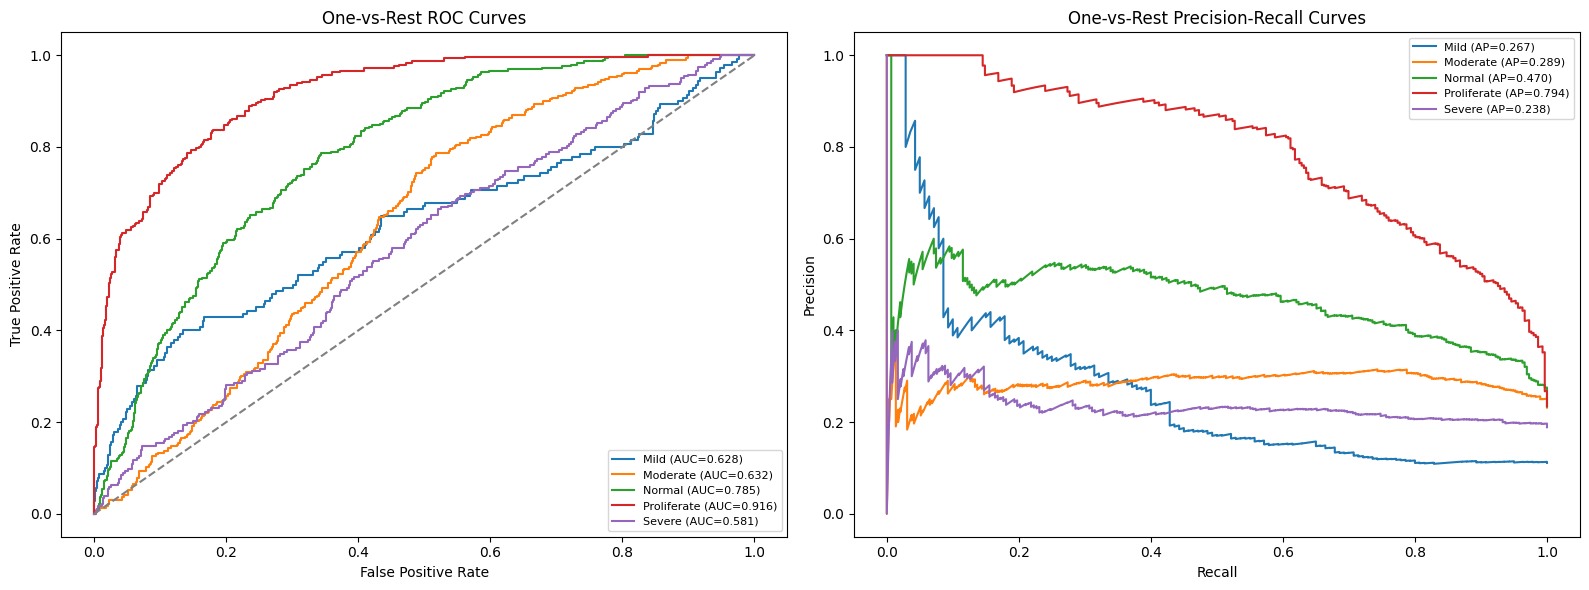

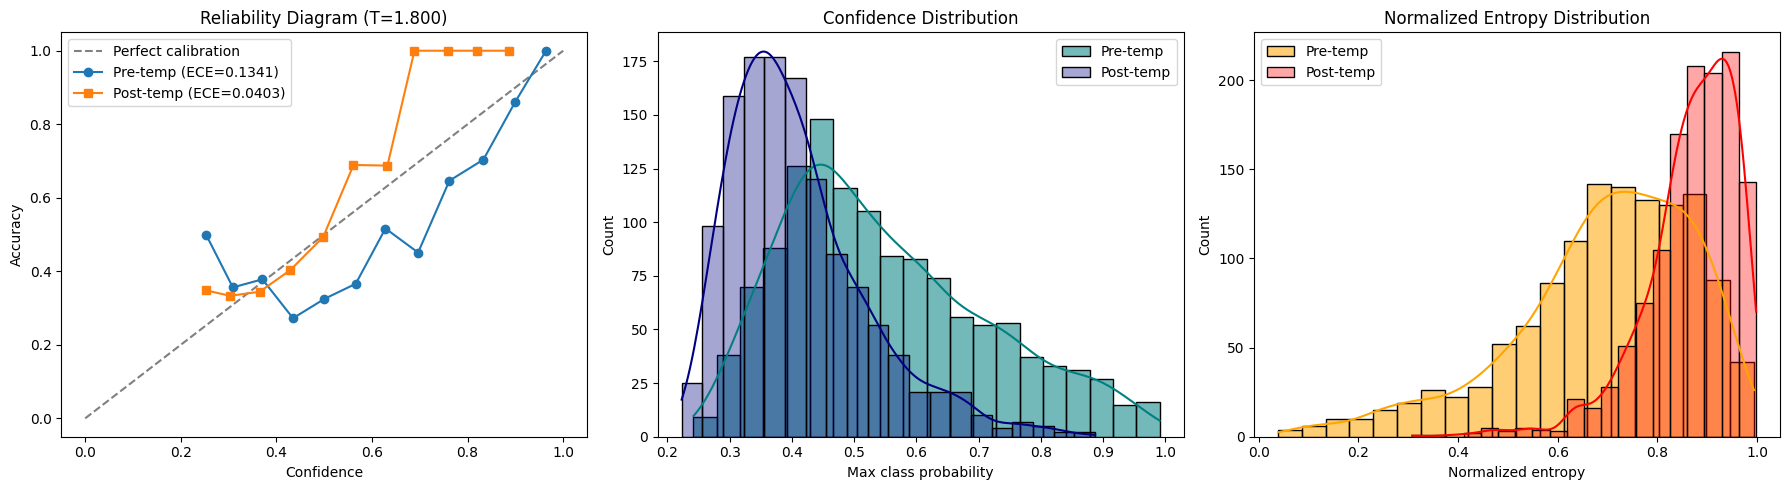

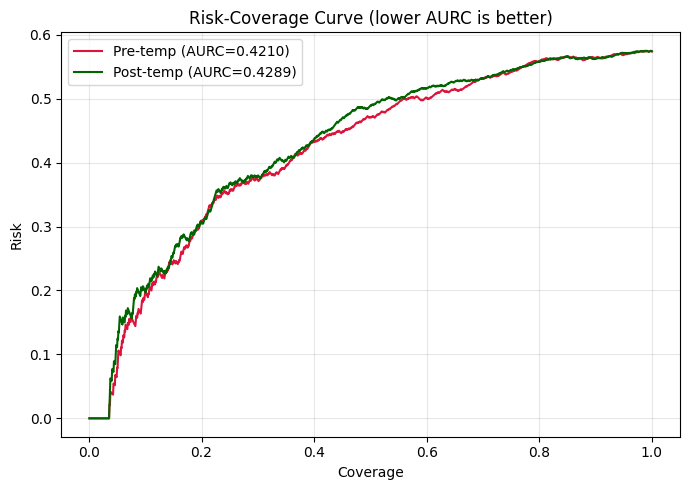

- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/uq_mc_dropout_metrics.csv
Saved plots to:
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/training_curves.png
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/confusion_matrices.png
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/per_class_prf.png
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/probability_covariance.png
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/roc_pr_curves.png
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/uq_reliability_and_distributions.png
- /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/eval/uq_risk_coverage.png


In [25]:
# Evaluation dashboard: export metrics and plots for reporting.
required_objects = [
    'metrics_df', 'per_class_df', 'cm', 'cm_normalized',
    'probability_covariance', 'y_true_onehot', 'val_probabilities',
    'classes', 'history_all', 'uq_summary_df', 'temperature_scaling_df',
    ]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        'Run the evaluation cells first. Missing objects: ' + ', '.join(missing_objects)
    )

eval_dir = ARTIFACTS_DIR / 'eval'
eval_dir.mkdir(parents=True, exist_ok=True)

# Save tabular metrics.
metrics_sorted = metrics_df.sort_values('metric').reset_index(drop=True)
metrics_sorted.to_csv(eval_dir / 'metrics_summary.csv', index=False)
per_class_df.to_csv(eval_dir / 'per_class_metrics.csv', index=False)
uq_summary_df.to_csv(eval_dir / 'uq_summary_metrics.csv', index=False)
temperature_scaling_df.to_csv(eval_dir / 'temperature_scaling_summary.csv', index=False)
if 'calibration_df' in globals() and not calibration_df.empty:
    calibration_df.to_csv(eval_dir / 'calibration_bins_pre_temp.csv', index=False)
if 'calibration_temp_df' in globals() and not calibration_temp_df.empty:
    calibration_temp_df.to_csv(eval_dir / 'calibration_bins_post_temp.csv', index=False)

print('Saved metrics to:')
print('-', eval_dir / 'metrics_summary.csv')
print('-', eval_dir / 'per_class_metrics.csv')
print('-', eval_dir / 'uq_summary_metrics.csv')
print('-', eval_dir / 'temperature_scaling_summary.csv')
if (eval_dir / 'calibration_bins_pre_temp.csv').exists():
    print('-', eval_dir / 'calibration_bins_pre_temp.csv')
if (eval_dir / 'calibration_bins_post_temp.csv').exists():
    print('-', eval_dir / 'calibration_bins_post_temp.csv')
display(metrics_sorted)

# 1) Training curves.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_all['loss'], label='train_loss')
axes[0].plot(history_all['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_all['accuracy'], label='train_accuracy')
axes[1].plot(history_all['val_accuracy'], label='val_accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(eval_dir / 'training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

# 2) Confusion matrices.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

sns.heatmap(
    cm_normalized, annot=True, fmt='.2f', cmap='Greens', xticklabels=classes, yticklabels=classes, ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

fig.tight_layout()
fig.savefig(eval_dir / 'confusion_matrices.png', dpi=180, bbox_inches='tight')
plt.show()

# 3) Per-class precision/recall/F1.
plot_df = per_class_df.melt(id_vars=['class', 'support'], value_vars=['precision', 'recall', 'f1'])
fig = plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x='class', y='value', hue='variable', palette='Set2')
plt.ylim(0, 1.0)
plt.title('Per-Class Precision, Recall, and F1')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.tight_layout()
fig.savefig(eval_dir / 'per_class_prf.png', dpi=180, bbox_inches='tight')
plt.show()

# 4) Covariance of predicted probabilities.
fig = plt.figure(figsize=(8, 6))
sns.heatmap(
    probability_covariance,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    xticklabels=classes,
    yticklabels=classes,
    center=0,
    )
plt.title('Covariance Matrix of Predicted Probabilities')
plt.xlabel('Class')
plt.ylabel('Class')
plt.tight_layout()
fig.savefig(eval_dir / 'probability_covariance.png', dpi=180, bbox_inches='tight')
plt.show()

# 5) ROC and PR curves.
n_classes = len(classes)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for class_index, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, class_index], val_probabilities[:, class_index])
    pr, rc, _ = precision_recall_curve(y_true_onehot[:, class_index], val_probabilities[:, class_index])

    class_auc = auc(fpr, tpr)
    class_ap = average_precision_score(y_true_onehot[:, class_index], val_probabilities[:, class_index])

    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC={class_auc:.3f})')
    axes[1].plot(rc, pr, label=f'{class_name} (AP={class_ap:.3f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('One-vs-Rest ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

axes[1].set_title('One-vs-Rest Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(eval_dir / 'roc_pr_curves.png', dpi=180, bbox_inches='tight')
plt.show()

# 6) UQ visual artifacts including temperature scaling.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
if 'calibration_df' in globals() and not calibration_df.empty:
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    axes[0].plot(calibration_df['bin_confidence'], calibration_df['bin_accuracy'], marker='o', label=f'Pre-temp (ECE={ece:.4f})')
if 'calibration_temp_df' in globals() and not calibration_temp_df.empty:
    axes[0].plot(calibration_temp_df['bin_confidence'], calibration_temp_df['bin_accuracy'], marker='s', label=f'Post-temp (ECE={ece_temp:.4f})')
axes[0].set_title(f'Reliability Diagram (T={best_temperature:.3f})')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

sns.histplot(val_confidence, bins=20, kde=True, ax=axes[1], color='teal', alpha=0.55, label='Pre-temp')
sns.histplot(val_confidence_temp, bins=20, kde=True, ax=axes[1], color='navy', alpha=0.35, label='Post-temp')
axes[1].set_title('Confidence Distribution')
axes[1].set_xlabel('Max class probability')
axes[1].legend()

sns.histplot(normalized_entropy, bins=20, kde=True, ax=axes[2], color='orange', alpha=0.55, label='Pre-temp')
sns.histplot(normalized_entropy_temp, bins=20, kde=True, ax=axes[2], color='red', alpha=0.35, label='Post-temp')
axes[2].set_title('Normalized Entropy Distribution')
axes[2].set_xlabel('Normalized entropy')
axes[2].legend()

fig.tight_layout()
fig.savefig(eval_dir / 'uq_reliability_and_distributions.png', dpi=180, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(coverage_curve, risk_curve, color='crimson', label=f'Pre-temp (AURC={aurc:.4f})')
plt.plot(coverage_curve_temp, risk_curve_temp, color='darkgreen', label=f'Post-temp (AURC={aurc_temp:.4f})')
plt.title('Risk-Coverage Curve (lower AURC is better)')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(eval_dir / 'uq_risk_coverage.png', dpi=180, bbox_inches='tight')
plt.show()

if 'uq_mc_df' in globals():
    uq_mc_df.to_csv(eval_dir / 'uq_mc_dropout_metrics.csv', index=False)
    print('-', eval_dir / 'uq_mc_dropout_metrics.csv')

print('Saved plots to:')
for name in [
    'training_curves.png',
    'confusion_matrices.png',
    'per_class_prf.png',
    'probability_covariance.png',
    'roc_pr_curves.png',
    'uq_reliability_and_distributions.png',
    'uq_risk_coverage.png',
]:
    print('-', eval_dir / name)

In [26]:
final_model_path = ARTIFACTS_DIR / f'dr_{MODEL_NAME.lower()}_final.keras'
best_model.save(final_model_path)
print('Saved Keras model to', final_model_path)

Saved Keras model to /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/dr_efficientnetb0_final.keras


In [27]:
# TFLite export — runs in a subprocess so a conversion crash can't take down the notebook kernel.
# This is necessary on macOS Apple Silicon where the in-process converter is prone to OOM crashes.
import subprocess
import sys
import textwrap

tflite_path = ARTIFACTS_DIR / f'dr_{MODEL_NAME.lower()}.tflite'
keras_path = ARTIFACTS_DIR / f'best_{MODEL_NAME.lower()}.keras'

_script = textwrap.dedent(f'''
    import tensorflow as tf
    model = tf.keras.models.load_model(r'{keras_path}')
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open(r'{tflite_path}', 'wb') as f:
        f.write(tflite_model)
    print('TFLite saved to {tflite_path}')
''')

print('Running TFLite conversion in subprocess...')
result = subprocess.run(
    [sys.executable, '-c', _script],
    capture_output=True,
    text=True,
    timeout=300,
)

if result.returncode == 0:
    print(result.stdout.strip())
    print(f'File size: {tflite_path.stat().st_size / 1024 / 1024:.1f} MB')
else:
    print('TFLite conversion failed (subprocess returned non-zero).')
    print(result.stderr[-2000:] if result.stderr else '(no stderr)')

Running TFLite conversion in subprocess...
TFLite conversion failed (subprocess returned non-zero).
 with NUMA support.
2026-06-18 18:37:19.239401: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
W0000 00:00:1781829446.753279 4185383 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1781829446.753660 4185383 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-06-18 18:37:26.754285: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/l8/jtjbg0t514n6m4m41fhxztgh0000gq/T/tmpbezw63k9
2026-06-18 18:37:26.763668: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-18 18:37:26.763676: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/l8/

In [28]:
# Package experiment artifacts into a timestamped run folder.
import json
import shutil
from datetime import datetime

run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_dir = ARTIFACTS_DIR / 'runs' / f'{MODEL_NAME.lower()}_{run_stamp}'
run_dir.mkdir(parents=True, exist_ok=True)

# Resolve available model files.
model_candidates = [
    ARTIFACTS_DIR / f'dr_{MODEL_NAME.lower()}_final.keras',
    ARTIFACTS_DIR / f'best_{MODEL_NAME.lower()}.keras',
    checkpoint_path if 'checkpoint_path' in globals() else None,
]
model_candidates = [path for path in model_candidates if path is not None and path.exists()]

# Resolve optional TFLite export.
tflite_candidate = ARTIFACTS_DIR / f'dr_{MODEL_NAME.lower()}.tflite'
tflite_files = [tflite_candidate] if tflite_candidate.exists() else []

# Resolve evaluation exports.
eval_dir = ARTIFACTS_DIR / 'eval'
eval_files = []
if eval_dir.exists():
    eval_files = [path for path in eval_dir.iterdir() if path.is_file()]

copied_files = []

# Copy model files.
for src in model_candidates:
    dst = run_dir / src.name
    shutil.copy2(src, dst)
    copied_files.append(dst)

# Copy TFLite file if available.
for src in tflite_files:
    dst = run_dir / src.name
    shutil.copy2(src, dst)
    copied_files.append(dst)

# Copy evaluation tables and plots.
for src in eval_files:
    dst = run_dir / src.name
    shutil.copy2(src, dst)
    copied_files.append(dst)

# Save a concise run metadata file for experiment tracking.
run_metadata = {
    'timestamp': run_stamp,
    'model_name': MODEL_NAME,
    'img_size': list(IMG_SIZE),
    'batch_size': BATCH_SIZE,
    'epochs_head': EPOCHS_HEAD,
    'epochs_fine': EPOCHS_FINE,
    'learning_rate_head': LEARNING_RATE_HEAD,
    'learning_rate_fine': LEARNING_RATE_FINE,
    'train_samples': int(len(train_df)),
    'val_samples': int(len(val_df)),
    'num_classes': int(len(classes)),
    'classes': classes,
    'mixed_precision_policy': tf.keras.mixed_precision.global_policy().name,
    'copied_files': [str(path.name) for path in copied_files],
}

if 'metrics_df' in globals():
    run_metadata['metrics'] = {
        row['metric']: float(row['value'])
        for _, row in metrics_df.iterrows()
    }

metadata_path = run_dir / 'run_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as handle:
    json.dump(run_metadata, handle, indent=2)

print('Created run folder:', run_dir)
print('Copied files:')
for path in copied_files:
    print('-', path.name)
print('Metadata file:', metadata_path.name)

Created run folder: /Users/david/Documents/Repos/bruce/TEHI-AI-DR-project/artifacts/runs/efficientnetb0_20260618_183727
Copied files:
- dr_efficientnetb0_final.keras
- best_efficientnetb0.keras
- best_efficientnetb0.keras
- uq_mc_dropout_metrics.csv
- per_class_prf.png
- probability_covariance.png
- metrics_summary.csv
- uq_reliability_and_distributions.png
- roc_pr_curves.png
- calibration_bins_post_temperature.csv
- final_report_classification.csv
- temperature_scaling_summary.csv
- calibration_bins_pre_temp.csv
- uq_risk_coverage.png
- training_curves.png
- confusion_matrices.png
- per_class_metrics.csv
- temperature_scaling_reliability.png
- uq_summary_metrics.csv
- final_report_calibration.csv
- calibration_bins_pre_temperature.csv
- calibration_bins_post_temp.csv
Metadata file: run_metadata.json


## Notes and next experiments
- The default notebook config is `EfficientNetB0` with `(224, 224)` input for better kernel stability and mobile prototyping.
- The model build cell now supports automatic fallback through `MODEL_FALLBACK_ORDER` if a heavier backbone fails to initialize.
- If memory is still tight, reduce `BATCH_SIZE` to `4` and keep `MAP_PARALLEL_CALLS = 1` with `PREFETCH_BUFFER = 1`.
- After a stable full run, try `MODEL_NAME = 'EfficientNetB3'` and add `'EfficientNetB0'` in `MODEL_FALLBACK_ORDER` so training can continue automatically if B3 fails.
- For medical imaging work, keep a separate held-out test set and report macro F1, per-class recall, and confusion patterns.